In [1]:
import sys, os, json, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
from scipy import stats
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt

sys.path.append("../src")
from dataset import gather_samples, stratified_split, RiceLeafDataset, CLASSES

os.makedirs("../figures", exist_ok=True); os.makedirs("../tables", exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False})

ORDER = ["resnet50", "efficientnet_b0", "mobilenetv3_large", "convnext_tiny", "swin_tiny"]
NAMES = {"resnet50": "ResNet50", "efficientnet_b0": "EfficientNet-B0", "mobilenetv3_large": "MobileNetV3-Large",
         "convnext_tiny": "ConvNeXt-Tiny", "swin_tiny": "Swin-Tiny"}
CKPT_DIR = "../notebooks"
CV_FILES = {k: f"../results/cv/{k}_cv_results.json" for k in ORDER}
CV_FILES["convnext_tiny"] = "../results/cv/cv_results.json"   # 08 notebook এর ফাইল
SHORT = [c.replace("Rice ", "") for c in CLASSES]

def savefig(name):
    plt.savefig(f"../figures/{name}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"../figures/{name}.pdf", bbox_inches="tight")

def save_table(df, name):
    df.to_csv(f"../tables/{name}.csv", index=False)
    try:
        with open(f"../tables/{name}.tex", "w") as f:
            f.write(df.to_latex(index=False, na_rep="--"))
    except Exception as e:
        print("LaTeX skip:", e)
print(device, CLASSES)

cuda ['Healthy', 'Insect', 'Leaf Scald', 'Rice Blast', 'Rice Leaffolder', 'Rice Stripes', 'Rice Tungro']


In [2]:
samples = gather_samples()
_, _, test_s = stratified_split(samples)
test_loader = DataLoader(RiceLeafDataset(test_s, split="test"), batch_size=32, shuffle=False, num_workers=2)
print("test size:", len(test_s))

def build_model(name, n=7):
    if name == "resnet50":
        m = models.resnet50(weights=None); m.fc = nn.Linear(m.fc.in_features, n)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None); m.classifier[1] = nn.Linear(m.classifier[1].in_features, n)
    elif name == "mobilenetv3_large":
        m = models.mobilenet_v3_large(weights=None); m.classifier[3] = nn.Linear(m.classifier[3].in_features, n)
    elif name == "convnext_tiny":
        m = models.convnext_tiny(weights=None); m.classifier[2] = nn.Linear(m.classifier[2].in_features, n)
    elif name == "swin_tiny":
        m = models.swin_t(weights=None); m.head = nn.Linear(m.head.in_features, n)
    return m

@torch.no_grad()
def predict(model):
    model.eval(); ys, ps = [], []
    for x, y in test_loader:
        ps.append(model(x.to(device)).argmax(1).cpu().numpy()); ys.append(np.asarray(y))
    return np.concatenate(ys), np.concatenate(ps)

PRED, PARAMS = {}, {}
for key in ORDER:
    for tag, suffix in [("wce", ""), ("focal", "_focal")]:
        m = build_model(key)
        m.load_state_dict(torch.load(f"{CKPT_DIR}/{key}{suffix}_best.pth", map_location="cpu"))
        m.to(device)
        PRED[(key, tag)] = predict(m)
        PARAMS[key] = sum(p.numel() for p in m.parameters()) / 1e6
        del m; torch.cuda.empty_cache()

single_f1  = {k: f1_score(*PRED[(k, "wce")], average="macro") for k in ORDER}
single_acc = {k: accuracy_score(*PRED[(k, "wce")]) for k in ORDER}
focal_f1   = {k: f1_score(*PRED[(k, "focal")], average="macro") for k in ORDER}
print("WCE  :", {k: round(v, 4) for k, v in single_f1.items()})
print("Focal:", {k: round(v, 4) for k, v in focal_f1.items()})

test size: 413
WCE  : {'resnet50': 0.7346, 'efficientnet_b0': 0.7483, 'mobilenetv3_large': 0.7234, 'convnext_tiny': 0.7215, 'swin_tiny': 0.7682}
Focal: {'resnet50': 0.7348, 'efficientnet_b0': 0.7391, 'mobilenetv3_large': 0.7298, 'convnext_tiny': 0.7398, 'swin_tiny': 0.751}


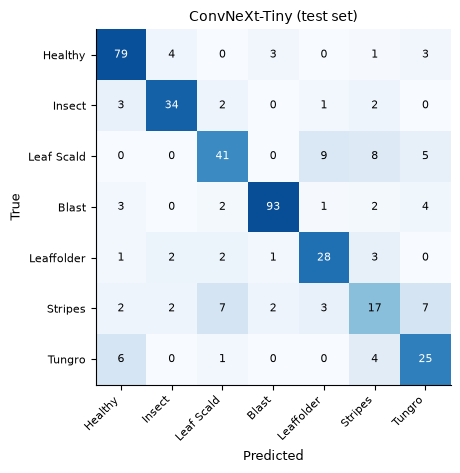

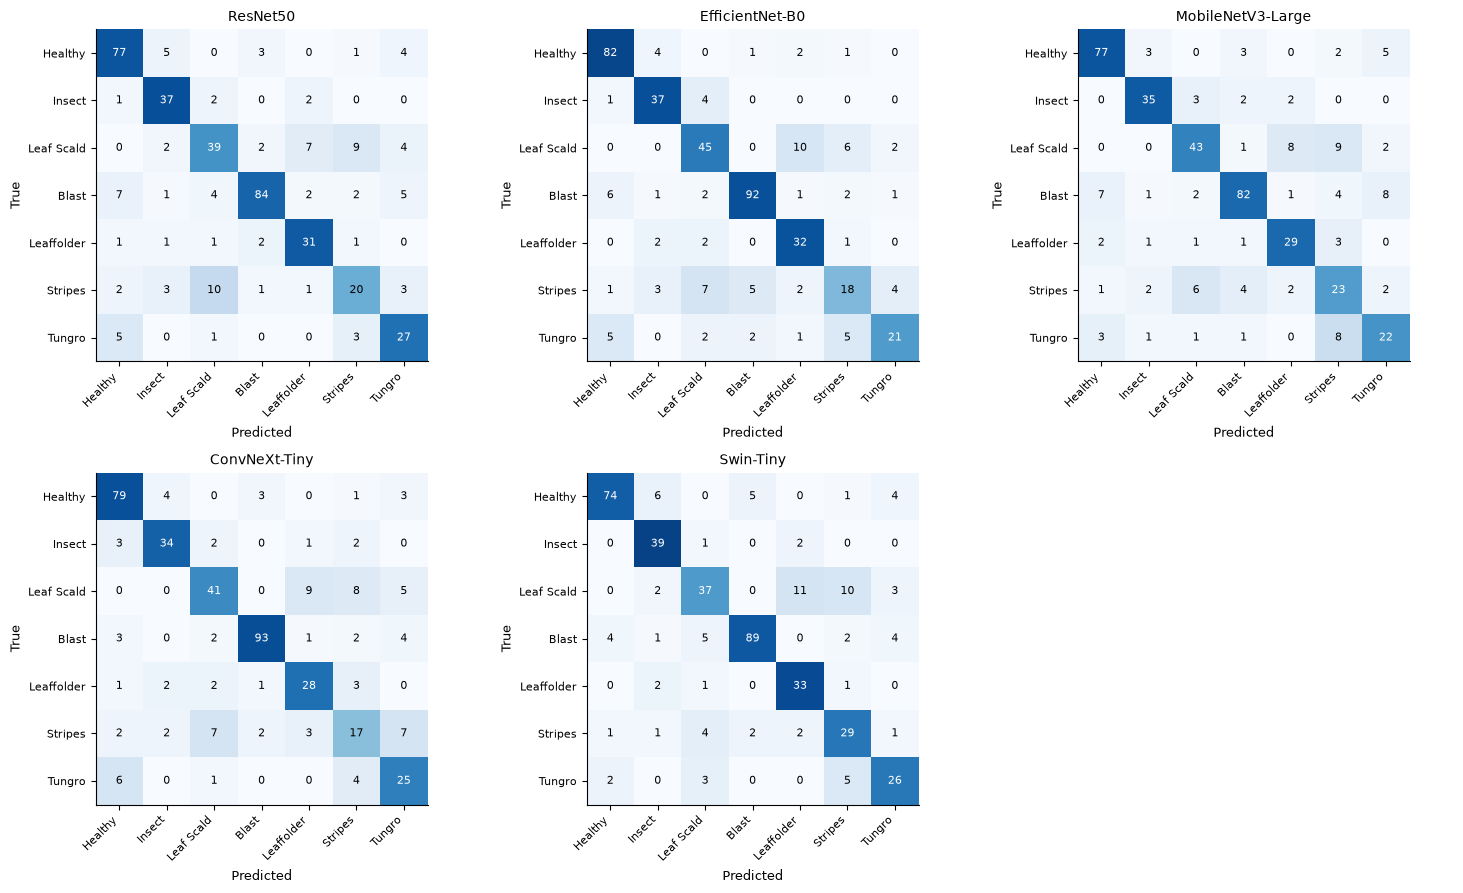

In [3]:
def draw_cm(ax, y, p, title):
    cm = confusion_matrix(y, p, labels=range(len(CLASSES)))
    cmn = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(7)); ax.set_yticks(range(7))
    ax.set_xticklabels(SHORT, rotation=45, ha="right", fontsize=8); ax.set_yticklabels(SHORT, fontsize=8)
    for i in range(7):
        for j in range(7):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cmn[i, j] > 0.5 else "black")
    ax.set_title(title, fontsize=10); ax.set_xlabel("Predicted"); ax.set_ylabel("True")

fig, ax = plt.subplots(figsize=(5.2, 4.8))
draw_cm(ax, *PRED[("convnext_tiny", "wce")], "ConvNeXt-Tiny (test set)")
plt.tight_layout(); savefig("cm_convnext_tiny"); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, key in zip(axes.ravel(), ORDER):
    draw_cm(ax, *PRED[(key, "wce")], NAMES[key])
axes.ravel()[-1].axis("off")
plt.tight_layout(); savefig("cm_all_models"); plt.show()

In [4]:
INF_MS = {"resnet50": np.nan, "efficientnet_b0": 8.44, "mobilenetv3_large": 7.60,
          "convnext_tiny": 9.63, "swin_tiny": 12.90}   # শর্ত (batch/GPU/precision) paper এ লিখতে হবে

t1 = pd.DataFrame({"Model": [NAMES[k] for k in ORDER],
                   "Params (M)": [round(PARAMS[k], 2) for k in ORDER],
                   "Accuracy": [round(single_acc[k], 4) for k in ORDER],
                   "Macro-F1": [round(single_f1[k], 4) for k in ORDER],
                   "Inference (ms)": [INF_MS[k] for k in ORDER]})
save_table(t1, "table1_single_split"); print(t1, "\n")

t2 = pd.DataFrame({"Model": [NAMES[k] for k in ORDER],
                   "WCE Macro-F1": [round(single_f1[k], 4) for k in ORDER],
                   "Focal Macro-F1": [round(focal_f1[k], 4) for k in ORDER]})
t2["Delta"] = (t2["Focal Macro-F1"] - t2["WCE Macro-F1"]).round(4)
save_table(t2, "table2_focal_ablation"); print(t2, "\n")

pcs = pd.DataFrame({NAMES[k]: f1_score(*PRED[(k, "wce")], average=None, labels=list(range(7))) for k in ORDER},
                   index=CLASSES).round(3)
pcs.reset_index(names="Class").to_csv("../tables/single_split_per_class_f1.csv", index=False)
print(pcs)

               Model  Params (M)  Accuracy  Macro-F1  Inference (ms)
0           ResNet50       23.52    0.7627    0.7346             NaN
1    EfficientNet-B0        4.02    0.7918    0.7483            8.44
2  MobileNetV3-Large        4.21    0.7530    0.7234            7.60
3      ConvNeXt-Tiny       27.83    0.7676    0.7215            9.63
4          Swin-Tiny       27.52    0.7918    0.7682           12.90 

               Model  WCE Macro-F1  Focal Macro-F1   Delta
0           ResNet50        0.7346          0.7348  0.0002
1    EfficientNet-B0        0.7483          0.7391 -0.0092
2  MobileNetV3-Large        0.7234          0.7298  0.0064
3      ConvNeXt-Tiny        0.7215          0.7398  0.0183
4          Swin-Tiny        0.7682          0.7510 -0.0172 

                 ResNet50  EfficientNet-B0  MobileNetV3-Large  ConvNeXt-Tiny  \
Healthy             0.842            0.886              0.856          0.859   
Insect              0.813            0.831              0.824       

CV loaded: ['resnet50', 'efficientnet_b0', 'mobilenetv3_large', 'convnext_tiny', 'swin_tiny'] | missing: []
               Model         Macro-F1         Accuracy
0      ConvNeXt-Tiny  0.7602 ± 0.0297  0.7820 ± 0.0297
1           ResNet50  0.7435 ± 0.0254  0.7657 ± 0.0248
2    EfficientNet-B0  0.7429 ± 0.0136  0.7730 ± 0.0140
3          Swin-Tiny  0.7417 ± 0.0288  0.7682 ± 0.0266
4  MobileNetV3-Large  0.7303 ± 0.0271  0.7490 ± 0.0274 

                           Comparison  Mean diff (F1)  Folds won (of 5)  \
0           ConvNeXt-Tiny vs ResNet50          0.0167                 4   
1    ConvNeXt-Tiny vs EfficientNet-B0          0.0172                 4   
2          ConvNeXt-Tiny vs Swin-Tiny          0.0185                 4   
3  ConvNeXt-Tiny vs MobileNetV3-Large          0.0299                 4   

   p (uncorrected)  p (Holm)  
0            0.051     0.202  
1            0.238     0.475  
2            0.309     0.475  
3            0.125     0.376   

                 ConvNeXt-T

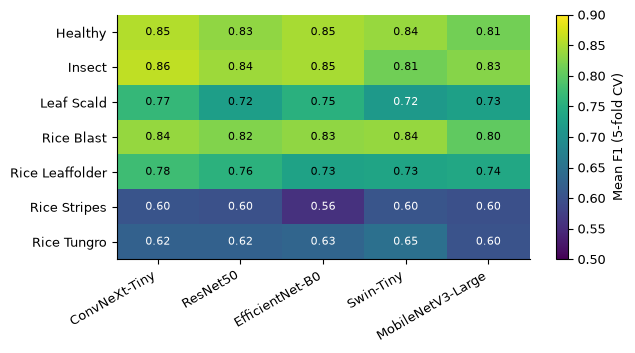

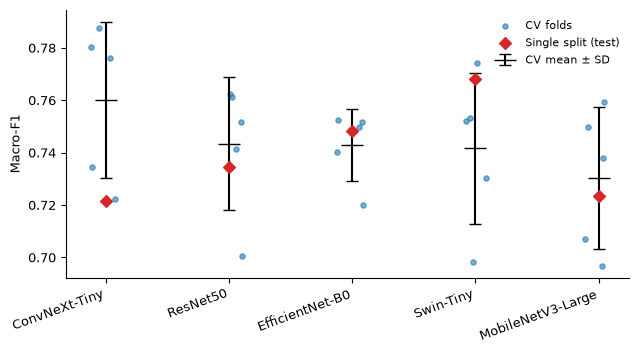

In [5]:
R = {k: json.load(open(p)) for k, p in CV_FILES.items() if os.path.exists(p)}
print("CV loaded:", list(R), "| missing:", [k for k in ORDER if k not in R])
cvF1  = {k: np.array([r["macro_f1"] for r in R[k]]) for k in R}
cvAcc = {k: np.array([r["acc"] for r in R[k]]) for k in R}
rank = sorted(R, key=lambda k: -cvF1[k].mean())

t3 = pd.DataFrame({"Model": [NAMES[k] for k in rank],
                   "Macro-F1": [f"{cvF1[k].mean():.4f} ± {cvF1[k].std(ddof=1):.4f}" for k in rank],
                   "Accuracy": [f"{cvAcc[k].mean():.4f} ± {cvAcc[k].std(ddof=1):.4f}" for k in rank]})
save_table(t3, "table3_cv"); print(t3, "\n")

# paired t-test (ConvNeXt vs বাকিগুলো), Holm সংশোধনসহ
ref, rows = "convnext_tiny", []
for k in rank:
    if k == ref or ref not in cvF1: continue
    t, p = stats.ttest_rel(cvF1[ref], cvF1[k])
    rows.append([f"{NAMES[ref]} vs {NAMES[k]}", cvF1[ref].mean() - cvF1[k].mean(),
                 int((cvF1[ref] > cvF1[k]).sum()), p])
ps = np.array([r[3] for r in rows]); order = np.argsort(ps); m = len(ps); adj = np.empty(m); run = 0.0
for rk, idx in enumerate(order):
    run = max(run, (m - rk) * ps[idx]); adj[idx] = min(1.0, run)
t_p = pd.DataFrame({"Comparison": [r[0] for r in rows], "Mean diff (F1)": [round(r[1], 4) for r in rows],
                    "Folds won (of 5)": [r[2] for r in rows], "p (uncorrected)": ps.round(3),
                    "p (Holm)": adj.round(3)})
save_table(t_p, "table3b_paired_tests"); print(t_p, "\n")

# CV per-class mean F1
pc = pd.DataFrame({NAMES[k]: np.array([r["per_class_f1"] for r in R[k]]).mean(0) for k in rank},
                  index=CLASSES).round(3)
pc.reset_index(names="Class").to_csv("../tables/cv_per_class_f1.csv", index=False); print(pc)

# Fig: CV per-class heatmap
fig, ax = plt.subplots(figsize=(6.5, 3.6))
im = ax.imshow(pc.values, cmap="viridis", vmin=0.5, vmax=0.9, aspect="auto")
ax.set_xticks(range(pc.shape[1])); ax.set_xticklabels(pc.columns, rotation=30, ha="right")
ax.set_yticks(range(7)); ax.set_yticklabels(CLASSES)
for i in range(pc.shape[0]):
    for j in range(pc.shape[1]):
        ax.text(j, i, f"{pc.values[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if pc.values[i, j] < 0.72 else "black")
plt.colorbar(im, ax=ax, label="Mean F1 (5-fold CV)"); plt.tight_layout()
savefig("cv_per_class_heatmap"); plt.show()

# Fig: single split বনাম CV (ranking অস্থিরতা)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
rng = np.random.default_rng(0)
for i, k in enumerate(rank):
    ax.scatter(i + rng.uniform(-0.12, 0.12, len(cvF1[k])), cvF1[k], s=14, color="tab:blue", alpha=0.6,
               label="CV folds" if i == 0 else None)
    ax.errorbar(i, cvF1[k].mean(), yerr=cvF1[k].std(ddof=1), fmt="_", color="black", capsize=4, ms=16,
                label="CV mean ± SD" if i == 0 else None)
    if k in single_f1:
        ax.scatter(i, single_f1[k], marker="D", s=36, color="tab:red", zorder=5,
                   label="Single split (test)" if i == 0 else None)
ax.set_xticks(range(len(rank))); ax.set_xticklabels([NAMES[k] for k in rank], rotation=20, ha="right")
ax.set_ylabel("Macro-F1"); ax.legend(frameon=False, fontsize=8); plt.tight_layout()
savefig("cv_vs_single_split"); plt.show()

In [6]:
# External test: 09_External_Test notebook এর আউটপুট থেকে (inference only, ConvNeXt-Tiny weighted CE)
ext = pd.DataFrame({
    "Dataset": ["RiceLeafBD", "Sethy et al."],
    "Classes used (n)": ["Blast (1440), Tungro (1308)", "Healthy (252), Tungro (530)"],
    "7-way acc.": [0.083, 0.390],
    "Restricted acc.": [0.526, 0.849],
    "Balanced acc.": [0.51, 0.88],
    "Per-class recall (restricted)": ["Blast 0.83, Tungro 0.20", "Healthy 0.98, Tungro 0.79"]})
save_table(ext, "table4_external"); print(ext)
print(sorted(os.listdir("../figures"))); print(sorted(os.listdir("../tables")))

        Dataset             Classes used (n)  7-way acc.  Restricted acc.  \
0    RiceLeafBD  Blast (1440), Tungro (1308)       0.083            0.526   
1  Sethy et al.  Healthy (252), Tungro (530)       0.390            0.849   

   Balanced acc. Per-class recall (restricted)  
0           0.51       Blast 0.83, Tungro 0.20  
1           0.88     Healthy 0.98, Tungro 0.79  
['cm_all_models.pdf', 'cm_all_models.png', 'cm_convnext_tiny.pdf', 'cm_convnext_tiny.png', 'cv_per_class_heatmap.pdf', 'cv_per_class_heatmap.png', 'cv_vs_single_split.pdf', 'cv_vs_single_split.png', 'gradcam_all_classes.png', 'gradcam_rice_stripes.png']
['cv_folds.csv', 'cv_folds.tex', 'cv_model_comparison.csv', 'cv_model_comparison.tex', 'cv_per_class.csv', 'cv_per_class.tex', 'cv_per_class_all.csv', 'cv_per_class_f1.csv', 'external_test.csv', 'external_test.tex', 'model_comparison.csv', 'model_comparison.tex', 'single_split_per_class_f1.csv', 'table1_single_split.csv', 'table1_single_split.tex', 'table2_focal_ab

In [ ]:
import time
@torch.no_grad()
def bench(key, n_warm=30, n_run=200, bs=1):
    m = build_model(key).to(device).eval()
    x = torch.randn(bs, 3, 224, 224, device=device)
    for _ in range(n_warm): m(x)
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_run): m(x)
    if device.type == "cuda": torch.cuda.synchronize()
    ms = (time.perf_counter() - t0) / n_run * 1000
    del m; torch.cuda.empty_cache()
    return ms

LAT = {k: bench(k) for k in ORDER}                                  # batch 1, fp32, 224x224
THR = {k: 32 / bench(k, bs=32, n_run=50) * 1000 for k in ORDER}     # images/s, batch 32
bench_df = pd.DataFrame({"Model": [NAMES[k] for k in ORDER],
                         "Latency (ms/img, bs=1)": [round(LAT[k], 2) for k in ORDER],
                         "Throughput (img/s, bs=32)": [round(THR[k], 1) for k in ORDER]})
save_table(bench_df, "table_inference_benchmark"); print(bench_df)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")